# 1. Question Closeness and Decomposition

This notebook does two things:

1. **Question decomposition** — split each market question into a *qualitative semantic core* (the underlying event) and a *quantitative parametric part* (date/time deadlines, numeric thresholds, count conditions). This separation is necessary to distinguish true duplicates from reframings.

2. **Closeness evaluation** — compute pairwise similarity signals and evaluate them against weak labels, including a new reframing-aware taxonomy.

### Closeness taxonomy

| Type | Qualitative similarity | Quantitative part | Example |
|---|---|---|---|
| `EXACT_DUPLICATE` | very high | identical | same question, same deadline |
| `REFRAMING` | very high | different | "end by 7 days" vs "end by 30 days" |
| `RELATED_EVENT` | moderate | varies | same topic, different events |
| `UNRELATED` | low | varies | unrelated questions |

### Why this matters for the benchmark

Side Idea 7 (outdated-prior belief update) requires excluding reframings: we want one canonical question per event family, not multiple parameterized variants of the same underlying question. This notebook provides the tooling to do that split.

## Imports and configuration

In [1]:
import ast
import itertools
import re
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics.pairwise import cosine_similarity

from polymarket_research import PolymarketDataset
from polymarket_research.data.canonical import CanonicalDatasetBuilder
from polymarket_research.data.raw import RawExternalCovariates
from polymarket_research.utils import setup_root

REPO_ROOT = setup_root()
CANONICAL_CACHE_DIR = REPO_ROOT / 'research_notebooks' / 'running_artefacts_new' / 'canonical_dataset'

# ── Scope: NO domain filter.
# The 'domain' column is currently 'unassigned' for all markets.
# Domains will be *derived* from question-closeness results in this notebook,
# not used as input. We filter purely by probability coverage and volume.
MAX_MARKETS = 50000           # cap to keep O(N²) pairwise computation tractable
MIN_PROBABILITY_ROWS = 288  # at least ~1 day of 5-min snapshots
MIN_VOLUME = 1000           # focus on markets with some trading activity
RESAMPLE_FREQ = '1h'
TOP_K = 5

# Closeness taxonomy thresholds
EXACT_DUP_THRESHOLD = 0.95   # qual-core cosine >= this + same quant → EXACT_DUPLICATE
RELATED_THRESHOLD   = 0.40   # qual-core cosine >= this → RELATED_EVENT

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', None)


## Load canonical dataset

We use the canonical resolved-markets layer. If no parquet cache exists, we build from the raw layer.

In [2]:
if (CANONICAL_CACHE_DIR / 'markets.parquet').exists():
    from polymarket_research.data.canonical import CanonicalDataset
    canonical = CanonicalDataset.from_parquet(CANONICAL_CACHE_DIR)
    print('Loaded canonical from parquet cache:', CANONICAL_CACHE_DIR)
else:
    raw_dataset = PolymarketDataset()
    raw_dataset.load(include_raw_trades=False)
    raw_external = RawExternalCovariates().load()
    canonical = CanonicalDatasetBuilder(
        raw_dataset=raw_dataset,
        raw_external=raw_external,
        resolved_only=True,
    ).build()
    print('Built canonical from SQLite')

all_markets = canonical.markets.copy()
probabilities = canonical.probabilities.copy()
print(f'Canonical resolved markets: {len(all_markets)}')
display(all_markets[['market_id', 'question', 'domain', 'family_id', 'volume_num']].head(5))

Loaded canonical from parquet cache: /Users/sneddy/research/polymarket_research/research_notebooks/running_artefacts_new/canonical_dataset
Canonical resolved markets: 15662


,market_id,question,domain,family_id,volume_num
0,1914442,"Will Hegseth say ""AI"" or ""Cyber"" during press conference?",unassigned,unassigned::::hegseth say ai or cyber during,38222.744674
1,1912772,"Trump announces US x Iran ceasefire end by April 8, 2026?",unassigned,unassigned::::trump announces us x iran ceasefire,38220.348645
2,1908626,Trump announces Hormuz deadline extension today?,unassigned,unassigned::::trump announces hormuz deadline extension today,987122.280619
3,1891746,"Will Trump say ""Strait"" or ""Hormuz"" during events with Rutte?",unassigned,unassigned::::trump say strait or hormuz during,27053.816874
4,1882888,Will Trump's remarks not air?,unassigned,unassigned::::trump s remarks not air,33098.189315


## Filter working scope

In [3]:
markets = (
    all_markets[
        all_markets['probability_rows'].fillna(0).ge(MIN_PROBABILITY_ROWS)
        & all_markets['volume_num'].fillna(0).ge(MIN_VOLUME)
    ]
    .sort_values('volume_num', ascending=False)
    .head(MAX_MARKETS)
    .reset_index(drop=True)
    .copy()
)

print(f'Working scope: {len(markets)} markets')
print(f'  probability_rows >= {MIN_PROBABILITY_ROWS}: covers {all_markets["probability_rows"].fillna(0).ge(MIN_PROBABILITY_ROWS).sum()} markets in total')
print(f'  volume_num >= {MIN_VOLUME}: covers {all_markets["volume_num"].fillna(0).ge(MIN_VOLUME).sum()} markets in total')
display(markets[["market_id", "question", "volume_num", "probability_rows", "family_id"]].head(10))


Working scope: 2292 markets
  probability_rows >= 288: covers 2292 markets in total
  volume_num >= 1000: covers 15662 markets in total


,market_id,question,volume_num,probability_rows,family_id
0,546814,Will Zelenskyy wear a suit before July?,2.422312e+08,13557.0,unassigned::::zelenskyy wear suit before july
1,601697,Fed decreases interest rates by 50+ bps after January 2026 meeting?,2.350652e+08,38219.0,unassigned::::fed decreases interest rates 50 bps
2,601700,Fed increases interest rates by 25+ bps after January 2026 meeting?,2.164557e+08,38298.0,unassigned::::fed increases interest rates 25 bps
3,654415,Will the Fed increase interest rates by 25+ bps after the March 2026 meeting?,1.729721e+08,40145.0,unassigned::::fed increase interest rates 25 bps
4,570360,Fed decreases interest rates by 50+ bps after December 2025 meeting?,1.615744e+08,37995.0,unassigned::::fed decreases interest rates 50 bps
5,680392,US government shutdown Saturday?,1.572966e+08,23726.0,unassigned::::us government shutdown saturday
6,538932,Will Zohran Mamdani win the 2025 NYC mayoral election?,1.432549e+08,56585.0,unassigned::::zohran mamdani win 2025 nyc mayoral
7,570363,Fed increases interest rates by 25+ bps after December 2025 meeting?,1.331736e+08,37885.0,unassigned::::fed increases interest rates 25 bps
8,1180303,Khamenei out as Supreme Leader of Iran by February 28?,1.311150e+08,14106.0,unassigned::::khamenei out as supreme leader iran
9,529278,Will Frances Fitzgerald win the Irish Presidential Election?,1.150672e+08,62889.0,unassigned::::frances fitzgerald win irish presidential election


---

# Part 1: Question Decomposition

We split each question into:
- **Qualitative core**: the underlying event — who, what, which entity.
- **Quantitative part**: numeric or temporal conditions — deadlines, thresholds, counts.

The decomposition uses regex patterns. We also use structural columns (`event_series_slug`, `group_item_title`, `neg_risk`) as weak validation signals.

In [4]:
# ─────────────────────────────────────────────────────────────────
# QuestionDecomposer
# ─────────────────────────────────────────────────────────────────

# Trigger patterns answer: when / by when does this resolve?
# Event text answers: what is the thing that might happen?
#
# Important modeling choice:
# - temporal / activation clauses like "before July", "after January 2026 meeting",
#   "by March 31", "Saturday" belong to trigger
# - scale / magnitude phrases like "by 50+ bps" remain part of the event
#
# We also resolve overlapping regex matches by keeping the longest leftmost span,
# so "by march 31" wins over a nested standalone "march 31".
_MONTH = r'(?:jan(?:uary)?|feb(?:ruary)?|mar(?:ch)?|apr(?:il)?|may|jun(?:e)?|jul(?:y)?|aug(?:ust)?|sep(?:tember)?|oct(?:ober)?|nov(?:ember)?|dec(?:ember)?)'
_DOW = r'(?:monday|tuesday|wednesday|thursday|friday|saturday|sunday)'
_QUARTER = r'(?:q[1-4](?:\s+\d{4})?|quarter\s+[1-4](?:\s+\d{4})?|h[12]\s+\d{4})'
_MEETING = rf'(?:the\s+)?{_MONTH}\s+\d{{4}}\s+meeting'
_DATE_POINT = rf'(?:{_MEETING}|(?:the\s+end\s+of\s+)?{_MONTH}(?:\s+\d{{1,2}}(?:,?\s+\d{{4}})?|\s+\d{{4}})?|(?:the\s+end\s+of\s+)?{_QUARTER}|(?:the\s+end\s+of\s+)?\d{{4}}|{_DOW})'
_TRIGGER_PATTERNS = [
    rf'\b(?:by|before|after|on)\s+{_DATE_POINT}\b',
    rf'\b{_DOW}\b',
    r'\bwithin\s+\d+\s+(?:day|week|month|hour|year)s?\b',
    r'\bin\s+\d{4}\b',
    r'\bby\s+(?:the\s+)?end\s+of\s+\d{4}\b',
    r'\bfirst\s+\d+\s+(?:day|week|month|hour)s?\b',
    r'\bnext\s+\d+\s+(?:day|week|month|hour)s?\b',
]
_TRIGGER_COMPILED = [re.compile(p, re.IGNORECASE) for p in _TRIGGER_PATTERNS]


def _normalize(text: str) -> str:
    text = str(text or '').lower()
    text = re.sub(r'[^a-z0-9\s\$%,.+]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def _select_non_overlapping_matches(patterns: list, text: str) -> list:
    candidates = []
    for order, pat in enumerate(patterns):
        for m in pat.finditer(text):
            candidates.append({
                'start': m.start(),
                'end': m.end(),
                'text': m.group().strip(),
                'order': order,
            })

    # Longest-leftmost wins; pattern order breaks ties.
    candidates.sort(key=lambda x: (x['start'], -(x['end'] - x['start']), x['order']))

    selected = []
    for cand in candidates:
        if any(not (cand['end'] <= kept['start'] or cand['start'] >= kept['end']) for kept in selected):
            continue
        selected.append(cand)

    selected.sort(key=lambda x: x['start'])
    return selected


def _remove_spans(text: str, spans: list) -> str:
    pieces = []
    cursor = 0
    for span in spans:
        pieces.append(text[cursor:span['start']])
        cursor = span['end']
    pieces.append(text[cursor:])
    cleaned = ' '.join(pieces)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned.strip(' ,')


@dataclass
class DecomposedQuestion:
    original: str
    decoupled_event: str
    decoupled_trigger: str
    trigger_candidates: list
    has_trigger: bool
    qual_core: str        # backward-compatible alias for decoupled_event
    quant_spans: list     # backward-compatible alias for [decoupled_trigger]
    has_quant: bool       # backward-compatible alias for has_trigger


def decompose_question(question: str) -> DecomposedQuestion:
    """Split a question into decoupled event and trigger spans."""
    norm = _normalize(question)
    trigger_matches = _select_non_overlapping_matches(_TRIGGER_COMPILED, norm)
    trigger_candidates = list(dict.fromkeys(match['text'] for match in trigger_matches))
    # Heuristic: when multiple trigger candidates exist, prefer the last one.
    # In market questions this is often the market-resolution clause,
    # while earlier temporal spans belong to the embedded event description.
    decoupled_trigger = trigger_candidates[-1] if trigger_candidates else ''
    chosen_matches = [trigger_matches[-1]] if trigger_matches else []
    decoupled_event = _remove_spans(norm, chosen_matches)
    return DecomposedQuestion(
        original=question,
        decoupled_event=decoupled_event,
        decoupled_trigger=decoupled_trigger,
        trigger_candidates=trigger_candidates,
        has_trigger=bool(decoupled_trigger),
        qual_core=decoupled_event,
        quant_spans=[decoupled_trigger] if decoupled_trigger else [],
        has_quant=bool(decoupled_trigger),
    )


# Apply decomposition
decomposed = markets['question'].apply(decompose_question)
markets['decoupled_event'] = [d.decoupled_event for d in decomposed]
markets['decoupled_trigger'] = [d.decoupled_trigger for d in decomposed]
markets['trigger_candidates'] = [d.trigger_candidates for d in decomposed]
markets['has_trigger'] = [d.has_trigger for d in decomposed]

# Backward-compatible aliases used later in the notebook.
markets['qual_core'] = [d.qual_core for d in decomposed]
markets['quant_spans'] = [d.quant_spans for d in decomposed]
markets['has_quant'] = [d.has_quant for d in decomposed]

print(f'Markets with trigger condition: {markets["has_trigger"].sum()} / {len(markets)} ({100*markets["has_trigger"].mean():.1f}%)')
display(markets[['question', 'decoupled_event', 'decoupled_trigger', 'has_trigger']].head(20))

Markets with trigger condition: 933 / 2292 (40.7%)


,question,decoupled_event,decoupled_trigger,has_trigger
0,Will Zelenskyy wear a suit before July?,will zelenskyy wear a suit,before july,True
1,Fed decreases interest rates by 50+ bps after January 2026 meeting?,fed decreases interest rates by 50+ bps,after january 2026 meeting,True
2,Fed increases interest rates by 25+ bps after January 2026 meeting?,fed increases interest rates by 25+ bps,after january 2026 meeting,True
3,Will the Fed increase interest rates by 25+ bps after the March 2026 meeting?,will the fed increase interest rates by 25+ bps,after the march 2026 meeting,True
4,Fed decreases interest rates by 50+ bps after December 2025 meeting?,fed decreases interest rates by 50+ bps,after december 2025 meeting,True
5,US government shutdown Saturday?,us government shutdown,saturday,True
6,Will Zohran Mamdani win the 2025 NYC mayoral election?,will zohran mamdani win the 2025 nyc mayoral election,,False
7,Fed increases interest rates by 25+ bps after December 2025 meeting?,fed increases interest rates by 25+ bps,after december 2025 meeting,True
8,Khamenei out as Supreme Leader of Iran by February 28?,khamenei out as supreme leader of iran,by february 28,True
9,Will Frances Fitzgerald win the Irish Presidential Election?,will frances fitzgerald win the irish presidential election,,False


## Validate decomposition with structural columns

We check whether `has_trigger` is consistent with structural markers:
- `neg_risk`: Polymarket's neg-risk mechanism creates parameterized variants.
- `event_series_slug`: markets in the same series often differ only in parameters.
- `group_item_title`: explicitly captures the variant title (e.g. "7 days", "30 days").

In [5]:
# Retrieve structural columns from raw market_universe if available
struct_cols = ['market_id', 'neg_risk', 'event_series_slug', 'group_item_title']
available_struct_cols = [c for c in struct_cols if c in all_markets.columns]

if len(available_struct_cols) > 1:
    struct = all_markets[available_struct_cols].copy()
    markets = markets.merge(struct, on='market_id', how='left')

    if 'neg_risk' in markets.columns:
        display(Markdown('### has_quant rate by neg_risk flag'))
        display(
            markets.groupby('neg_risk')['has_quant']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'quant_rate', 'count': 'n'})
        )

    if 'event_series_slug' in markets.columns:
        display(Markdown('### Largest event series'))
        series_sizes = markets.groupby('event_series_slug').size().sort_values(ascending=False).head(10)
        display(series_sizes)

    if 'group_item_title' in markets.columns:
        display(Markdown('### Sample group_item_title (parametric labels)'))
        display(markets[markets['group_item_title'].notna()][['question', 'group_item_title', 'qual_core', 'quant_spans']].head(15))
else:
    print('Structural columns not available in canonical dataset — skipping validation.')

## Decomposition diagnostics

How does the decoupled event differ in length from the original question? How many trigger spans are extracted per market?

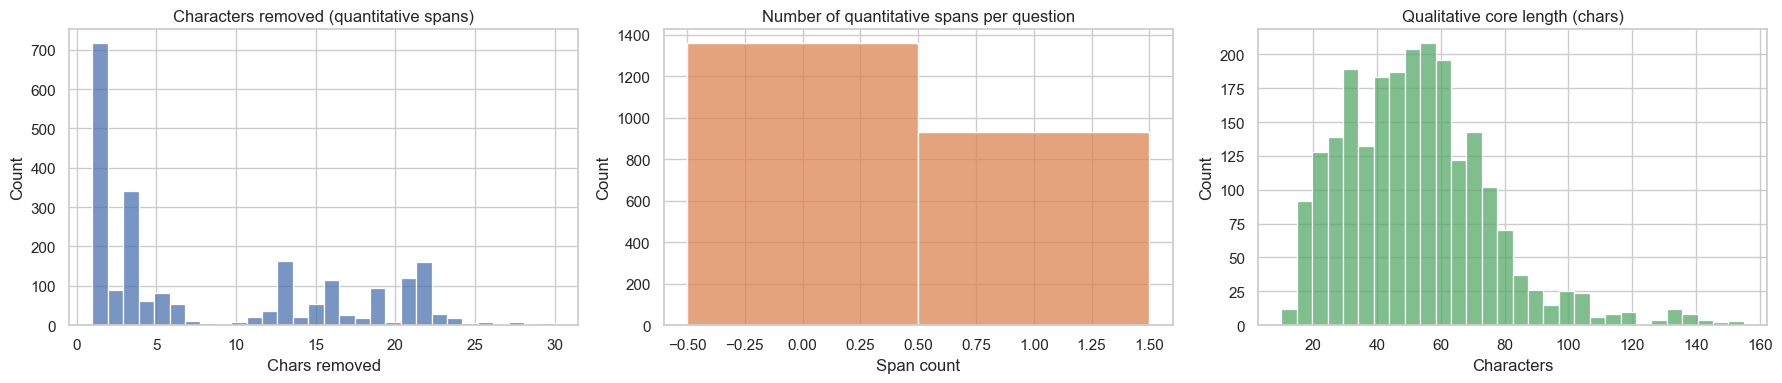

### Sample: questions with most quantitative content

,question,qual_core,quant_spans
0,Will Zelenskyy wear a suit before July?,will zelenskyy wear a suit,[before july]
983,Ilhan Omar federally charged by March 31?,ilhan omar federally charged,[by march 31]
1019,"Will Iran conduct a military action against Israel on March 28, 2026?",will iran conduct a military action against israel,"[on march 28, 2026]"
1018,Will there be exactly 1 earthquake of magnitude 6.5 or higher worldwide by March 29?,will there be exactly 1 earthquake of magnitude 6.5 or higher worldwide,[by march 29]
1015,"Will Israel strike Lebanon on February 23, 2026?",will israel strike lebanon,"[on february 23, 2026]"
1014,Will Trump sue Trevor Noah by March 31?,will trump sue trevor noah,[by march 31]
1011,Peter Mandelson charged by March 31?,peter mandelson charged,[by march 31]
1004,"Will Russia capture Bilytske by March 31, 2026?",will russia capture bilytske,"[by march 31, 2026]"
1003,Will Elon Musk’s net worth be between $670b and $680b on March 31?,will elon musk s net worth be between $670b and $680b,[on march 31]
1002,Will gas hit (High) $4.00 by March 31?,will gas hit high $4.00,[by march 31]


In [6]:
markets['original_len'] = markets['question'].str.len()
markets['qual_len'] = markets['qual_core'].str.len()
markets['quant_char_removed'] = markets['original_len'] - markets['qual_len']
markets['n_quant_spans'] = markets['quant_spans'].apply(len)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(markets['quant_char_removed'].clip(0, 100), bins=30, color='#4c72b0', ax=axes[0])
axes[0].set_title('Characters removed (quantitative spans)')
axes[0].set_xlabel('Chars removed')

sns.histplot(markets['n_quant_spans'], bins=range(0, 8), discrete=True, color='#dd8452', ax=axes[1])
axes[1].set_title('Number of quantitative spans per question')
axes[1].set_xlabel('Span count')

sns.histplot(markets['qual_len'], bins=30, color='#55a868', ax=axes[2])
axes[2].set_title('Qualitative core length (chars)')
axes[2].set_xlabel('Characters')

plt.tight_layout()
plt.show()

display(Markdown('### Sample: questions with most quantitative content'))
display(
    markets.sort_values('n_quant_spans', ascending=False)[['question', 'qual_core', 'quant_spans']].head(10)
)

In [27]:
markets

,market_id,condition_id,market_slug,event_id,event_slug,event_title,event_series_slug_x,question,description,resolution_source,...,quant_char_removed,n_quant_spans,text_blob,question_for_similarity,question_for_topics,topic_id,topic_confidence,topic_label,domain_lda,text_for_topics
0,546814,0x655e5ca101c466b6293aa15e06173b78b293221803d56e35551f708cd82eb352,will-zelenskyy-wear-a-suit-before-july,25044,will-zelenskyy-wear-a-suit-before-july,Will Zelenskyy wear a suit before July?,NaN,Will Zelenskyy wear a suit before July?,"This market will resolve to ""Yes"" if Volodymyr Zelenskyy is is photographed or videotaped wearing a suit between May 22 and June 30, 2025 ET. Otherwise, this market will resolve to ""No"".\n\nFor this market to resolve to ""Yes"" the images or video must be taken and released within this market's timeframe. The images or video must be authentic, not the result of artificial intelligence or video editing.\n\nThe resolution source will be a consensus of credible reporting.",,...,13,1,"Will Zelenskyy wear a suit before July? This market will resolve to ""Yes"" if Volodymyr Zelenskyy is is photographed or videotaped wearing a suit between May 22 and June 30, 2025 ET. Otherwise, this market will resolve to ""No"".\n\nFor this market to resolve to ""Yes"" the images or video must be taken and released within this market's timeframe. The images or video must be authentic, not the result of artificial intelligence or video editing.\n\nThe resolution source will be a consensus of credible reporting. []",Will Zelenskyy wear a suit before July?,Will Zelenskyy wear a suit before July?,5,0.550000,"topic_5: trump, march, worldwide, higher","topic_5: trump, march, worldwide, higher",will zelenskyy wear a suit
1,601697,0x17815081230e3b9c78b098162c33b1ffa68c4ec29c123d3d14989599e0c2e113,fed-decreases-interest-rates-by-50-bps-after-january-2026-meeting,45883,fed-decision-in-january,Fed decision in January?,fed-interest-rates,Fed decreases interest rates by 50+ bps after January 2026 meeting?,"The FED interest rates are defined in this market by the upper bound of the target federal funds range. The decisions on the target federal fund range are made by the Federal Open Market Committee (FOMC) meetings.\n\nThis market will resolve to the amount of basis points the upper bound of the target federal funds rate is changed by versus the level it was prior to the Federal Reserve's January 2026 meeting.\n\nIf the target federal funds rate is changed to a level not expressed in the displayed options, the change will be rounded up to the nearest 25 and will resolve to the relevant bracket. (e.g. if there's a cut/increase of 12.5 bps it will be considered to be 25 bps)\n\nThe resolution source for this market is the FOMC’s statement after its meeting scheduled for January 27 - 28, 2026 according to the official calendar: https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm.\n\nThe level and change of the target federal funds rate is also published at the official website of the Federal Reserve at https://www.federalreserve.gov/monetarypolicy/openmarket.htm.\n\nThis market may resolve as soon as the FOMC’s statement for their January meeting with relevant data is issued. If no statement is released by the end date of the next scheduled meeting, this market will resolve to the ""No change"" bracket.",,...,28,1,"Fed decreases interest rates by 50+ bps after January 2026 meeting? The FED interest rates are defined in this market by the upper bound of the target federal funds range. The decisions on the target federal fund range are made by the Federal Open Market Committee (FOMC) meetings.\n\nThis market will resolve to the amount of basis points the upper bound of the target federal funds rate is changed by versus the level it was prior to the Federal Reserve's January 2026 meeting.\n\nIf the target federal funds rate is changed to a level not expressed in the displayed options, the change will be rounded up to the nearest 25 a

# LDA

/Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'u', 'wa'] not in stop_words.
  warnings.warn(


LDA fitted on qualitative/event text with 10 topics
Vocabulary size: 7887
Stop words used: 318

topic_0: qualify, isw, yes, consensus credible, reporting, map
Top words: qualify, isw, yes, consensus credible, reporting, map, date, credible, consensus, credible reporting, 11, information, 59, 11 59, 59 pm, pm, control, pm et, official, resolve yes, source market, primary, 2026 11, primary resolution, government, et market, http, isw map, russian, used

Examples:
  1336363 | conf=0.997 | Will Russia capture all of Huliaipole by February 28?
  1418674 | conf=0.997 | Will Russia capture all of Huliaipole by March 31?
  1336153 | conf=0.997 | Will Russia capture all of Rodynske by February 28?
  1302787 | conf=0.997 | Will Russia capture all of Ternuvate by February 28, 2026?
  1336157 | conf=0.997 | Will Russia capture all of Drobysheve by March 31?
  1320797 | conf=0.997 | Will Russia capture all of Myrnohrad by March 31?
  1320800 | conf=0.997 | Will Russia capture all of Pokrovsk by Mar

,market_id,question,text_for_topics,topic_id,topic_confidence,topic_label
348,1336363,Will Russia capture all of Huliaipole by February 28?,"This market will resolve to “Yes” if, according to the ISW map, Russia captures the entirety of Huliaipole, Zaporizhzhya Oblast, (47°39'45.5""N 36°15'13.1""E) by February 28, 2026, 11:59 PM ET.\n\nHuliaipole will be considered captured if the entirety of the municipality is shaded red on the ISW map (https://storymaps.arcgis.com/stories/36a7f6a6f5a9448496de641cf64bd375) by the resolution date. If the area is not shaded red by February 28, 2026, 11:59 PM ET, the market will resolve to “No”.\n\nFor any change on the ISW map to qualify for this market’s resolution, the relevant shading indicating Russian control must persist through the next full ISW daily update cycle. If ISW skips a day, shading must persist until the next finalized ISW update is published, regardless of the date. Any continuous shading which reflects either “Assessed Russian Control”, “Assessed Russian Advance In Ukraine”, or “Assessed Russian Gains in the Past 24 Hours” will qualify. “Assessed Russian Infiltration Areas in Ukraine” will not qualify.\n\nThe territory of the municipality is shaded in light grey and is distinguished from bordering municipalities with a darker grey line. If all area within the municipality is shaded in red, however, the shading does not precisely match up with the border such that there is a tiny amount of grey along the border of the city, this will still qualify for a ""Yes"" resolution.\n\nOnce Russia captures the entirety of Huliaipole, any subsequent loss of control will not be considered towards the resolution of this market.\n\nLocation on Google maps: https://maps.app.goo.gl/vXBbP9idYDbbC21RA\n\nThe primary resolution source for this market will be the ISW Ukraine map. If the ISW map is rendered unavailable, information from DeepStateMap (https://deepstatemap.live/) may be used. If information from both the ISW and DeepStateMap are rendered permanently unavailable, a consensus of credible reporting may be used.\n\nNote: Any temporary glitches or errors in the map which will not be considered.\n\nIf Russia comes into control of this territory as a result of a negotiated settlement, this will qualify for a 'Yes' resolution, regardless of if it is shaded red in the ISW map. An announcement of a negotiated settlement which gives Russia de jure control will not qualify. Actual control must be established.",0,0.997500,"topic_0: qualify, isw, yes, consensus credible"
571,1418674,Will Russia capture all of Huliaipole by March 31?,"This market will resolve to “Yes” if, according to the ISW map, Russia captures the entirety of Huliaipole, Zaporizhzhya Oblast, (47°39'45.5""N 36°15'13.1""E) by March 31, 2026, 11:59 PM ET.\n\nHuliaipole will be considered captured if the entirety of the municipality is shaded red on the ISW map (https://storymaps.arcgis.com/stories/36a7f6a6f5a9448496de641cf64bd375) by the resolution date. If the area is not shaded red by March 31, 2026, 11:59 PM ET, the market will resolve to “No”.\n\nFor any change on the ISW map to qualify for this market’s resolution, the relevant shading indicating Russian control must persist through the next full ISW daily update cycle. If ISW skips a day, shading must persist until the next finalized ISW update is published, regardless of the date. Any continuous shading which reflects either “Assessed Russian Control”, “Assessed Russian Advance In Ukraine”, or “Assessed Russian Gains in the Past 24 Hours” will qualify. “Assessed Russian Infiltration Areas in Ukraine” will not qualify.\n\nThe territory of the municipality is shaded in light grey and is distinguished from bordering municipalities with a darker grey line. If all area within the municipality is shaded in red, however, the shading does not precisely match up with the border such that there is a tiny amount of grey along the border of the city, this will still qualify for a ""Y

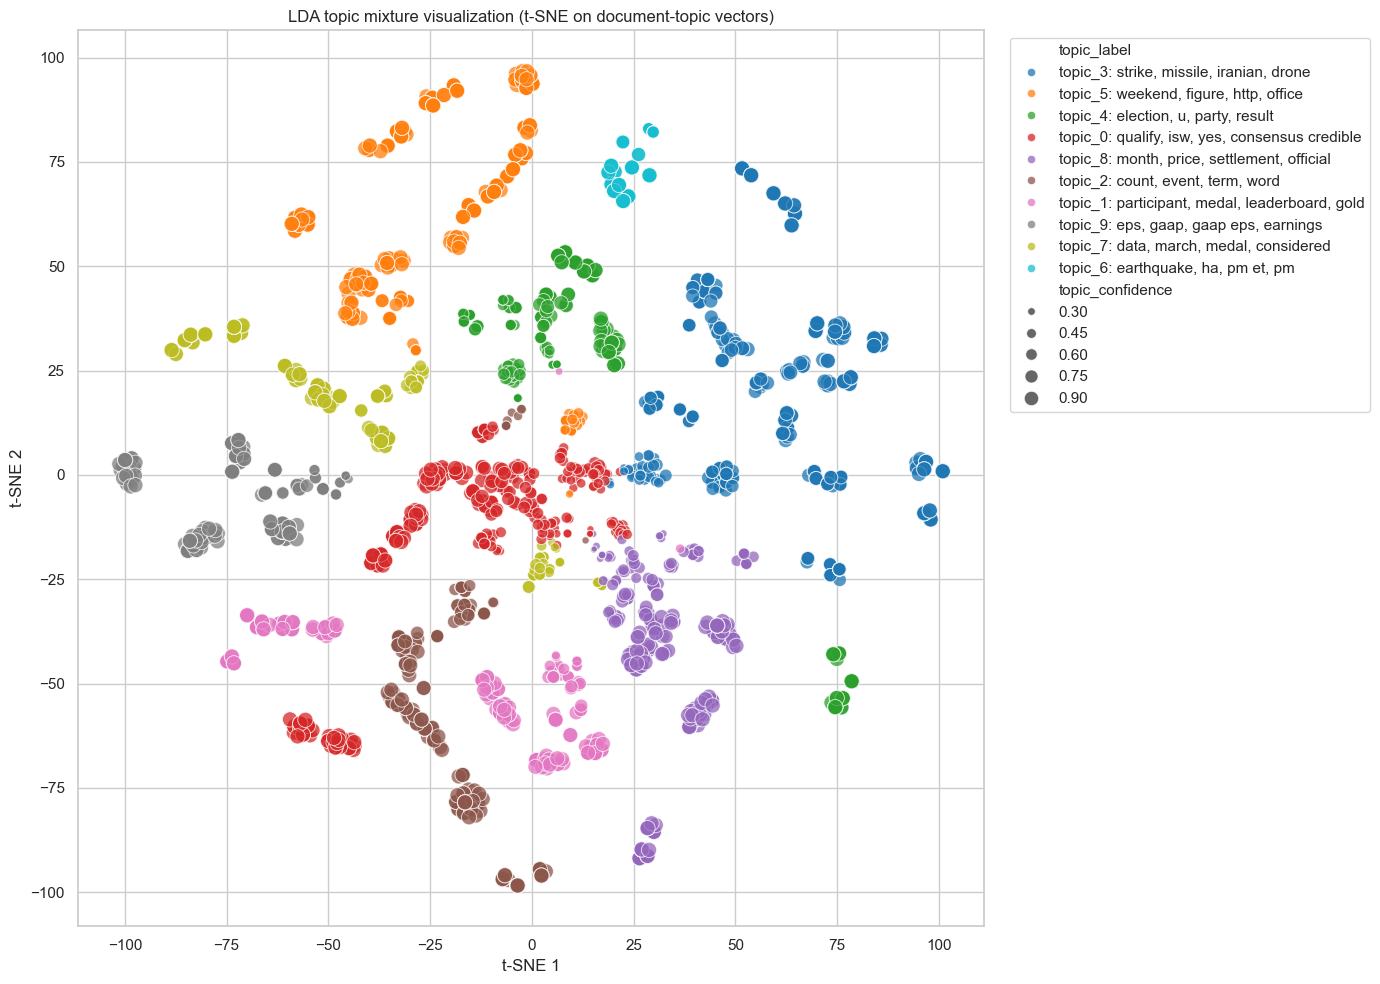

/Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'u', 'wa'] not in stop_words.
  warnings.warn(


LDA fitted on qualitative/event text with 10 topics
Vocabulary size: 7887
Stop words used: 318

topic_0: qualify, isw, yes, consensus credible, reporting, map
Top words: qualify, isw, yes, consensus credible, reporting, map, date, credible, consensus, 11, credible reporting, information, 59, 11 59, 59 pm, pm, control, pm et, official, resolve yes, source market, 2026 11, primary, primary resolution, government, http, et market, used, isw map, russian

Examples:
  1336363 | conf=0.997 | Will Russia capture all of Huliaipole by February 28?
  1418674 | conf=0.997 | Will Russia capture all of Huliaipole by March 31?
  1336153 | conf=0.997 | Will Russia capture all of Rodynske by February 28?
  1302787 | conf=0.997 | Will Russia capture all of Ternuvate by February 28, 2026?
  1336157 | conf=0.997 | Will Russia capture all of Drobysheve by March 31?
  1320797 | conf=0.997 | Will Russia capture all of Myrnohrad by March 31?
  1320800 | conf=0.997 | Will Russia capture all of Pokrovsk by Mar

,market_id,question,text_for_topics,topic_id,topic_confidence,topic_label
348,1336363,Will Russia capture all of Huliaipole by February 28?,"This market will resolve to “Yes” if, according to the ISW map, Russia captures the entirety of Huliaipole, Zaporizhzhya Oblast, (47°39'45.5""N 36°15'13.1""E) by February 28, 2026, 11:59 PM ET.\n\nHuliaipole will be considered captured if the entirety of the municipality is shaded red on the ISW map (https://storymaps.arcgis.com/stories/36a7f6a6f5a9448496de641cf64bd375) by the resolution date. If the area is not shaded red by February 28, 2026, 11:59 PM ET, the market will resolve to “No”.\n\nFor any change on the ISW map to qualify for this market’s resolution, the relevant shading indicating Russian control must persist through the next full ISW daily update cycle. If ISW skips a day, shading must persist until the next finalized ISW update is published, regardless of the date. Any continuous shading which reflects either “Assessed Russian Control”, “Assessed Russian Advance In Ukraine”, or “Assessed Russian Gains in the Past 24 Hours” will qualify. “Assessed Russian Infiltration Areas in Ukraine” will not qualify.\n\nThe territory of the municipality is shaded in light grey and is distinguished from bordering municipalities with a darker grey line. If all area within the municipality is shaded in red, however, the shading does not precisely match up with the border such that there is a tiny amount of grey along the border of the city, this will still qualify for a ""Yes"" resolution.\n\nOnce Russia captures the entirety of Huliaipole, any subsequent loss of control will not be considered towards the resolution of this market.\n\nLocation on Google maps: https://maps.app.goo.gl/vXBbP9idYDbbC21RA\n\nThe primary resolution source for this market will be the ISW Ukraine map. If the ISW map is rendered unavailable, information from DeepStateMap (https://deepstatemap.live/) may be used. If information from both the ISW and DeepStateMap are rendered permanently unavailable, a consensus of credible reporting may be used.\n\nNote: Any temporary glitches or errors in the map which will not be considered.\n\nIf Russia comes into control of this territory as a result of a negotiated settlement, this will qualify for a 'Yes' resolution, regardless of if it is shaded red in the ISW map. An announcement of a negotiated settlement which gives Russia de jure control will not qualify. Actual control must be established.",0,0.997500,"topic_0: qualify, isw, yes, consensus credible"
571,1418674,Will Russia capture all of Huliaipole by March 31?,"This market will resolve to “Yes” if, according to the ISW map, Russia captures the entirety of Huliaipole, Zaporizhzhya Oblast, (47°39'45.5""N 36°15'13.1""E) by March 31, 2026, 11:59 PM ET.\n\nHuliaipole will be considered captured if the entirety of the municipality is shaded red on the ISW map (https://storymaps.arcgis.com/stories/36a7f6a6f5a9448496de641cf64bd375) by the resolution date. If the area is not shaded red by March 31, 2026, 11:59 PM ET, the market will resolve to “No”.\n\nFor any change on the ISW map to qualify for this market’s resolution, the relevant shading indicating Russian control must persist through the next full ISW daily update cycle. If ISW skips a day, shading must persist until the next finalized ISW update is published, regardless of the date. Any continuous shading which reflects either “Assessed Russian Control”, “Assessed Russian Advance In Ukraine”, or “Assessed Russian Gains in the Past 24 Hours” will qualify. “Assessed Russian Infiltration Areas in Ukraine” will not qualify.\n\nThe territory of the municipality is shaded in light grey and is distinguished from bordering municipalities with a darker grey line. If all area within the municipality is shaded in red, however, the shading does not precisely match up with the border such that there is a tiny amount of grey along the border of the city, this will still qualify for a ""Y

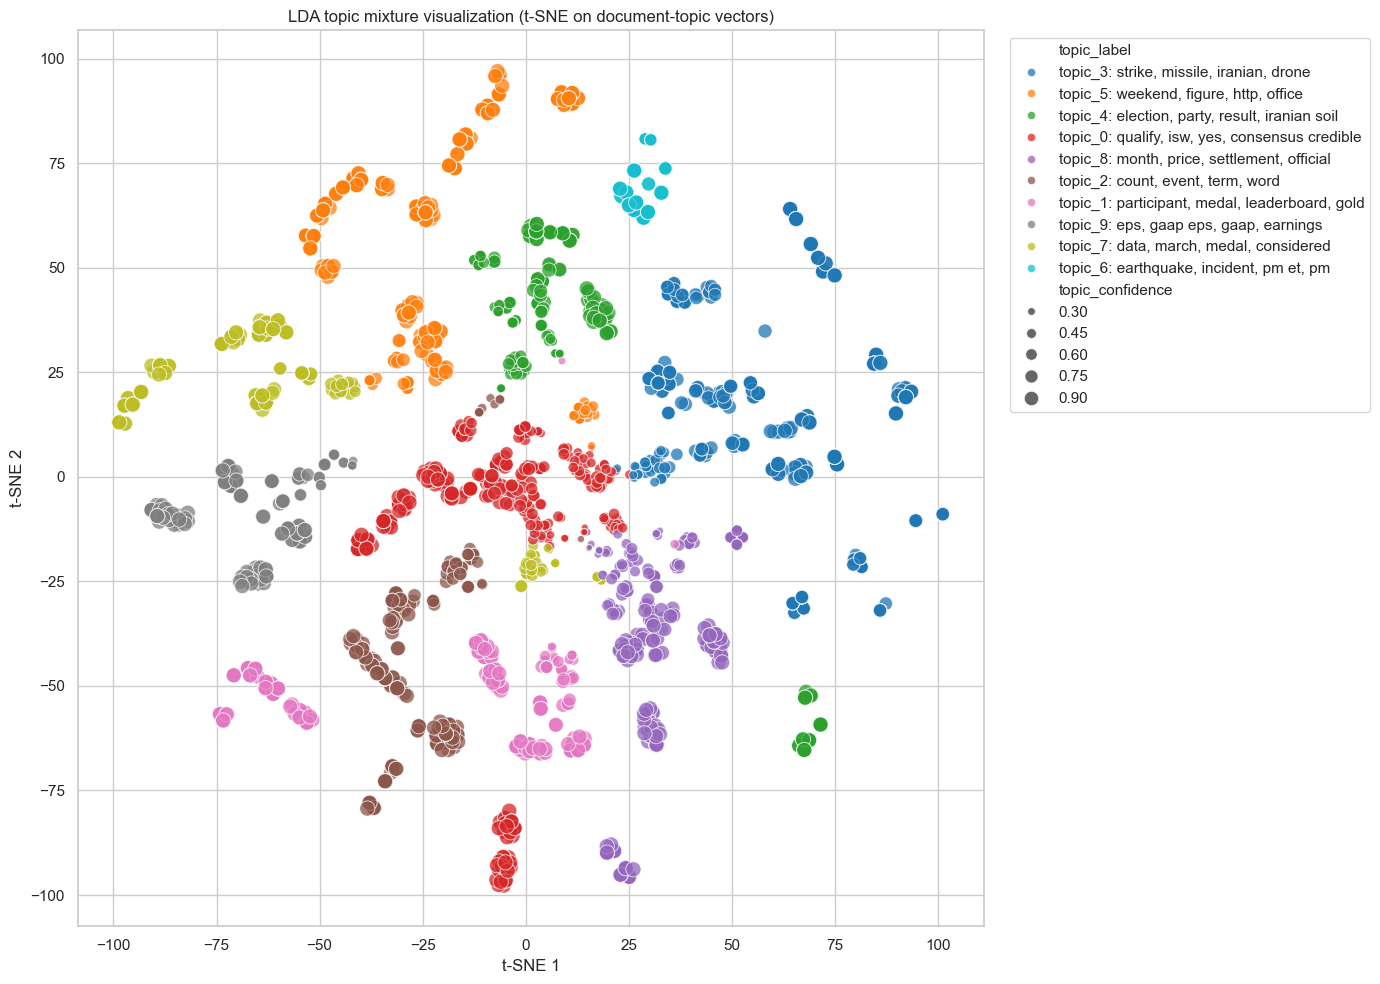

In [28]:
# LDA topic modeling on the qualitative/event part of the question
# Goal: derive coarse domains before TF-IDF similarity.
# sklearn LDA requires choosing the number of topics; start with 10.

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

N_TOPICS = 5
N_TOP_WORDS = 50
N_EXAMPLES_PER_TOPIC = 10

# Use the same normalization/tokenization logic as TF-IDF if available.
# Prefer decoupled_event / qual_core over raw question.
markets['text_for_topics'] = (
    markets.get('decoupled_event', markets.get('qual_core', markets['question']))
    .fillna('')
    .astype(str)
)

if 'lemma_tokenizer' not in globals():
    import re
    import nltk
    from nltk.stem import WordNetLemmatizer

    try:
        nltk.data.find('corpora/wordnet')
    except LookupError:
        nltk.download('wordnet')

    lemmatizer = WordNetLemmatizer()
    TOKEN_RE = re.compile(r"(?u)\b[\w$%.+-]+\b")

    def lemma_tokenizer(text: str) -> list[str]:
        text = str(text or '').lower()
        tokens = TOKEN_RE.findall(text)
        return [lemmatizer.lemmatize(tok) for tok in tokens if len(tok) > 1]

# For LDA/domain discovery, stop words are useful to suppress generic function words.
# Keep a small allowlist of temporal words out of the stoplist in case they are domain-relevant.
# Goal: derive coarse domains before TF-IDF similarity.
# sklearn LDA requires choosing the number of topics; start with 10.

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

N_TOPICS = 10
N_TOP_WORDS = 30
N_EXAMPLES_PER_TOPIC = 30

# Use the same normalization/tokenization logic as TF-IDF if available.
# Prefer decoupled_event / qual_core over raw question.
markets['text_for_topics'] = (
    markets.get('description', markets.get('qual_core', markets['question']))
    .fillna('')
    .astype(str)
)

if 'lemma_tokenizer' not in globals():
    import re
    import nltk
    from nltk.stem import WordNetLemmatizer

    try:
        nltk.data.find('corpora/wordnet')
    except LookupError:
        nltk.download('wordnet')

    lemmatizer = WordNetLemmatizer()
    TOKEN_RE = re.compile(r"(?u)\b[\w$%.+-]+\b")

    def lemma_tokenizer(text: str) -> list[str]:
        text = str(text or '').lower()
        tokens = TOKEN_RE.findall(text)
        return [lemmatizer.lemmatize(tok) for tok in tokens if len(tok) > 1]

# For LDA/domain discovery, stop words are useful to suppress generic function words.
# Keep a small allowlist of temporal words out of the stoplist in case they are domain-relevant.
lda_stop_words = sorted(set(ENGLISH_STOP_WORDS))

vec_lda = CountVectorizer(
    tokenizer=lemma_tokenizer,
    preprocessor=None,
    lowercase=False,
    token_pattern=None,
    stop_words=lda_stop_words,
    min_df=5,
    max_df=0.7,
    ngram_range=(1, 2),
)

X_lda = vec_lda.fit_transform(markets['text_for_topics'])

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method='batch',
    max_iter=30,
)
topic_mix = lda.fit_transform(X_lda)

feature_names = vec_lda.get_feature_names_out()

def top_words_for_topic(topic_idx: int, top_n: int = N_TOP_WORDS) -> list[str]:
    weights = lda.components_[topic_idx]
    top_ids = np.argsort(weights)[::-1][:top_n]
    return feature_names[top_ids].tolist()

topic_top_words = {
    topic_idx: top_words_for_topic(topic_idx)
    for topic_idx in range(N_TOPICS)
}

markets['topic_id'] = topic_mix.argmax(axis=1)
markets['topic_confidence'] = topic_mix.max(axis=1)
markets['topic_label'] = markets['topic_id'].map(
    lambda t: f"topic_{t}: " + ", ".join(topic_top_words[t][:4])
)

# Coarse domain candidate derived from dominant topic
markets['domain_lda'] = markets['topic_label']

print(f'LDA fitted on qualitative/event text with {N_TOPICS} topics')
print(f'Vocabulary size: {len(feature_names)}')
print(f'Stop words used: {len(lda_stop_words)}')
print()

for topic_idx in range(N_TOPICS):
    label = f"topic_{topic_idx}: " + ", ".join(topic_top_words[topic_idx][:6])
    print('=' * 120)
    print(label)
    print('Top words:', ', '.join(topic_top_words[topic_idx]))

    sample = (
        markets.loc[markets['topic_id'] == topic_idx, ['market_id', 'question', 'text_for_topics', 'topic_confidence']]
        .sort_values('topic_confidence', ascending=False)
        .head(N_EXAMPLES_PER_TOPIC)
        .reset_index(drop=True)
    )

    print('\nExamples:')
    if len(sample) == 0:
        print('  <no examples>')
    else:
        for _, row in sample.iterrows():
            print(f"  {row['market_id']} | conf={row['topic_confidence']:.3f} | {row['question']}")
    print()

display(
    markets[['market_id', 'question', 'text_for_topics', 'topic_id', 'topic_confidence', 'topic_label']]
    .sort_values(['topic_id', 'topic_confidence'], ascending=[True, False])
    .head(30)
)

# Visualization:
# Plot documents in topic-mixture space with t-SNE.
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=min(30, max(5, len(markets) // 100)),
    init='pca',
    learning_rate='auto',
)
topic_2d = tsne.fit_transform(topic_mix)

viz = markets[['market_id', 'question', 'topic_id', 'topic_confidence', 'topic_label']].copy().reset_index(drop=True)
viz['x'] = topic_2d[:, 0]
viz['y'] = topic_2d[:, 1]

plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=viz,
    x='x',
    y='y',
    hue='topic_label',
    size='topic_confidence',
    palette='tab10',
    alpha=0.75,
    sizes=(20, 120),
)
plt.title('LDA topic mixture visualization (t-SNE on document-topic vectors)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

lda_stop_words = sorted(set(ENGLISH_STOP_WORDS))

vec_lda = CountVectorizer(
    tokenizer=lemma_tokenizer,
    preprocessor=None,
    lowercase=False,
    token_pattern=None,
    stop_words=lda_stop_words,
    min_df=5,
    max_df=0.7,
    ngram_range=(1, 2),
)

X_lda = vec_lda.fit_transform(markets['text_for_topics'])

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method='batch',
    max_iter=50,
)
topic_mix = lda.fit_transform(X_lda)

feature_names = vec_lda.get_feature_names_out()

def top_words_for_topic(topic_idx: int, top_n: int = N_TOP_WORDS) -> list[str]:
    weights = lda.components_[topic_idx]
    top_ids = np.argsort(weights)[::-1][:top_n]
    return feature_names[top_ids].tolist()

topic_top_words = {
    topic_idx: top_words_for_topic(topic_idx)
    for topic_idx in range(N_TOPICS)
}

markets['topic_id'] = topic_mix.argmax(axis=1)
markets['topic_confidence'] = topic_mix.max(axis=1)
markets['topic_label'] = markets['topic_id'].map(
    lambda t: f"topic_{t}: " + ", ".join(topic_top_words[t][:4])
)

# Coarse domain candidate derived from dominant topic
markets['domain_lda'] = markets['topic_label']

print(f'LDA fitted on qualitative/event text with {N_TOPICS} topics')
print(f'Vocabulary size: {len(feature_names)}')
print(f'Stop words used: {len(lda_stop_words)}')
print()

for topic_idx in range(N_TOPICS):
    label = f"topic_{topic_idx}: " + ", ".join(topic_top_words[topic_idx][:6])
    print('=' * 120)
    print(label)
    print('Top words:', ', '.join(topic_top_words[topic_idx]))

    sample = (
        markets.loc[markets['topic_id'] == topic_idx, ['market_id', 'question', 'text_for_topics', 'topic_confidence']]
        .sort_values('topic_confidence', ascending=False)
        .head(N_EXAMPLES_PER_TOPIC)
        .reset_index(drop=True)
    )

    print('\nExamples:')
    if len(sample) == 0:
        print('  <no examples>')
    else:
        for _, row in sample.iterrows():
            print(f"  {row['market_id']} | conf={row['topic_confidence']:.3f} | {row['question']}")
    print()

display(
    markets[['market_id', 'question', 'text_for_topics', 'topic_id', 'topic_confidence', 'topic_label']]
    .sort_values(['topic_id', 'topic_confidence'], ascending=[True, False])
    .head(30)
)

# Visualization:
# Plot documents in topic-mixture space with t-SNE.
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=min(30, max(5, len(markets) // 100)),
    init='pca',
    learning_rate='auto',
)
topic_2d = tsne.fit_transform(topic_mix)

viz = markets[['market_id', 'question', 'topic_id', 'topic_confidence', 'topic_label']].copy().reset_index(drop=True)
viz['x'] = topic_2d[:, 0]
viz['y'] = topic_2d[:, 1]

plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=viz,
    x='x',
    y='y',
    hue='topic_label',
    size='topic_confidence',
    palette='tab10',
    alpha=0.75,
    sizes=(20, 120),
)
plt.title('LDA topic mixture visualization (t-SNE on document-topic vectors)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


---

# Part 2: Pairwise Closeness Signals

We compute:
- **Full-text cosine**: TF-IDF on the original question + description + tags (from existing pipeline).
- **Qual-core cosine**: TF-IDF on the qualitative core only — the key new signal.
- **Tag Jaccard**: overlap of tag sets.
- **Time overlap**: Jaccard of market lifetime windows.
- **Resolution source match**: same resolution URL.
- **Return correlation**: absolute Pearson correlation of hourly probability changes.
- **Combined score**: weighted combination.

In [7]:
# ─── helpers (reproduced from tickers_closeness for self-containment) ─────────

def parse_listish(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    if isinstance(value, list):
        return [str(x).strip() for x in value if str(x).strip()]
    text = str(value).strip()
    if not text:
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(x).strip() for x in parsed if str(x).strip()]
    except Exception:
        pass
    sep = '|' if '|' in text else ','
    return [p.strip() for p in text.split(sep) if p.strip()]


def tag_jaccard(tags_a, tags_b):
    a = set(parse_listish(tags_a))
    b = set(parse_listish(tags_b))
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)


def safe_corr(s_a: pd.Series, s_b: pd.Series, min_points: int = 12) -> float:
    pair = pd.concat([s_a, s_b], axis=1).dropna()
    if len(pair) < min_points:
        return np.nan
    a = pair.iloc[:, 0].to_numpy(float)
    b = pair.iloc[:, 1].to_numpy(float)
    if np.nanstd(a) <= 1e-12 or np.nanstd(b) <= 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def safe_auc(y_true, score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, score)


def safe_ap(y_true, score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, score)


def recall_at_k(pair_df: pd.DataFrame, score_col: str, label_col: str, k: int = 5) -> float:
    recalls = []
    for _, group in pair_df.groupby('market_id_a', sort=False):
        if group[label_col].sum() == 0:
            continue
        top = group.nlargest(k, score_col)
        recalls.append(float(top[label_col].sum() > 0))
    return float(np.mean(recalls)) if recalls else np.nan

In [16]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
TOKEN_RE = re.compile(r"(?u)\b[\w$%.+-]+\b")

def lemma_tokenizer(text: str) -> list[str]:
    text = str(text or '').lower()
    tokens = TOKEN_RE.findall(text)
    return [lemmatizer.lemmatize(tok) for tok in tokens if len(tok) > 1]

# Start simple: similarity on the raw question text, including quantitative parts.
markets['question_for_similarity'] = markets['question'].fillna('')

vec_question = TfidfVectorizer(
    min_df=2,
    max_features=5000,
    ngram_range=(1, 2),
    tokenizer=lemma_tokenizer,
    preprocessor=None,
    lowercase=False,
    token_pattern=None,
)

tfidf_question = vec_question.fit_transform(markets['question_for_similarity'])
cos_question = cosine_similarity(tfidf_question)   # shape (N, N)

print('TF-IDF matrix built on raw question text')
print(f'  Vocab size: {len(vec_question.vocabulary_)}')
print('  Lemmatization: WordNetLemmatizer')
print('  N-grams: unigrams + bigrams')


TF-IDF matrix built on raw question text
  Vocab size: 3270
  Lemmatization: WordNetLemmatizer
  N-grams: unigrams + bigrams


[nltk_data] Downloading package wordnet to /Users/sneddy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Explained variance by PCA(2): 0.049
Cluster sizes:


,n
cluster,
-1,269
0,18
1,5
2,3
3,6
...,...
182,4
183,4
184,4


/var/folders/zv/mjsbg2dx4q79c1gbwtlhbk180000gp/T/ipykernel_30995/3644504296.py:53: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


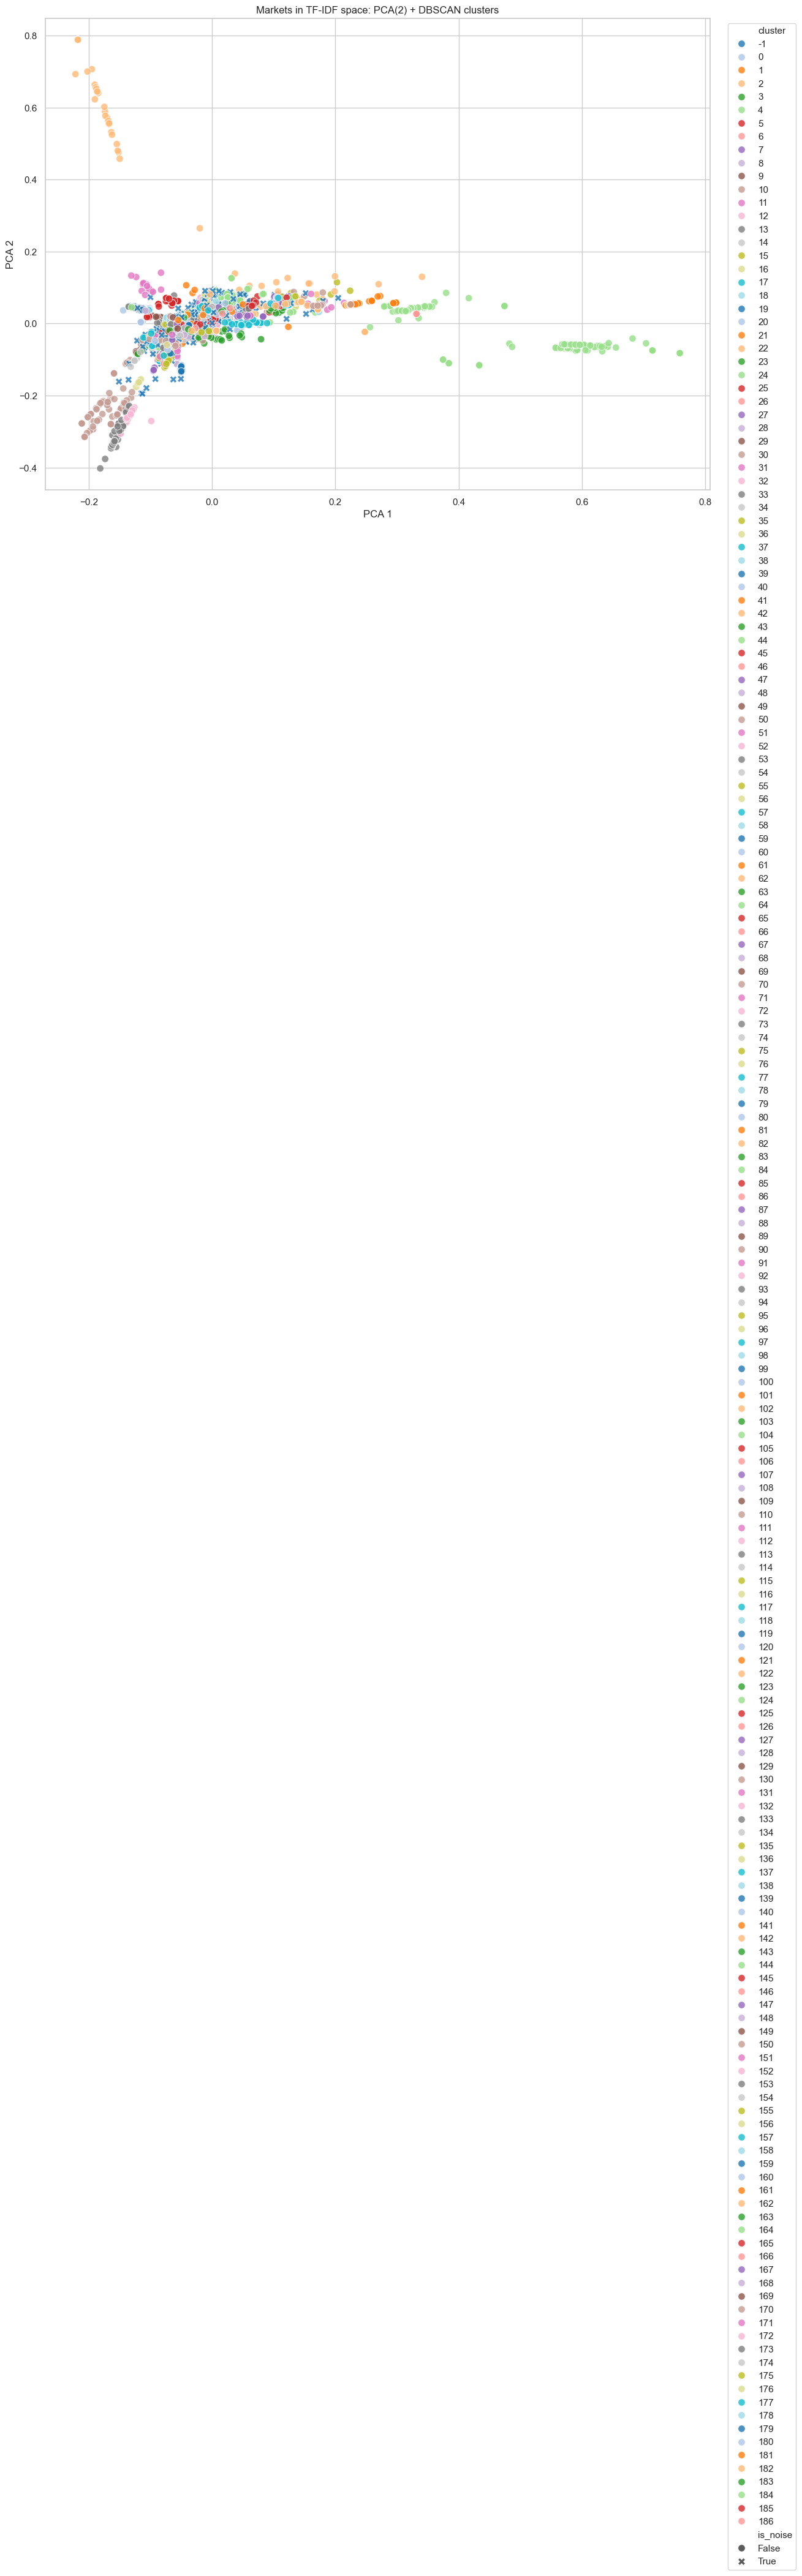

### Sample points per cluster

**noise**

,market_id,question
0,680392,US government shutdown Saturday?
1,529278,Will Frances Fitzgerald win the Irish Presidential Election?
2,1484949,Netanyahu out by March 31?
3,812010,"Will Eleven die in ""Stranger Things: Season 5""?"
4,551963,Xi Jinping out in 2025?
5,566331,Will Polymarket US go live in 2025?
6,958442,Will the Iranian regime fall by March 31?
7,686122,Lighter market cap (FDV) >$1B one day after launch?
8,552649,Israel x Iran ceasefire before July?
9,588775,US x Venezuela military engagement by December 31?


**cluster 0**

,market_id,question
0,601697,Fed decreases interest rates by 50+ bps after January 2026 meeting?
1,601700,Fed increases interest rates by 25+ bps after January 2026 meeting?
2,654415,Will the Fed increase interest rates by 25+ bps after the March 2026 meeting?
3,570360,Fed decreases interest rates by 50+ bps after December 2025 meeting?
4,570363,Fed increases interest rates by 25+ bps after December 2025 meeting?
5,553813,Fed increases interest rates by 25+ bps after October 2025 meeting?
6,601698,Fed decreases interest rates by 25 bps after January 2026 meeting?
7,654413,Will the Fed decrease interest rates by 25 bps after the March 2026 meeting?
8,542540,Fed increases interest rates by 25+ bps after September 2025 meeting?
9,570361,Fed decreases interest rates by 25 bps after December 2025 meeting?


...

,market_id,question
0,1230483,Will the Social Democratic Party loose any seats in Japanese snap election?
1,1230476,Will the Liberal Democratic Party loose any seats in Japanese snap election?
2,1230482,Will the Conservative Party of Japan loose any seats in Japanese snap election?
3,1230484,Will Team Mirai loose any seats in Japanese snap election?


**cluster 185**

,market_id,question
0,1348633,"Will Bernie Sanders say ""Obama"" during the Fighting Oligarchy rally?"
1,1348630,"Will Bernie Sanders say ""Epstein"" during the Fighting Oligarchy rally?"
2,1348620,"Will Bernie Sanders say ""Trump"" 15+ times during the Fighting Oligarchy rally?"
3,1348628,"Will Bernie Sanders say ""Affordability"" during the Fighting Oligarchy rally?"


**cluster 186**

,market_id,question
0,1385980,Will Jacob Bridgeman win the 2026 The Genesis Invitational?
1,1386067,Will Rory McIlroy win the 2026 The Genesis Invitational?
2,1538604,Will Xander Schauffele win the 2026 THE PLAYERS Championship?
3,1386087,Will Scottie Scheffler win the 2026 The Genesis Invitational?
4,1386089,Will Adam Scott win the 2026 The Genesis Invitational?
5,1386085,Will Xander Schauffele win the 2026 The Genesis Invitational?


In [17]:
# Visualize text similarity with PCA(2) and cluster with DBSCAN
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Choose which representation to inspect:
# - tfidf_question
# - tfidf_qual
# If you followed the simplified setup, use tfidf_question.
X = tfidf_question

# PCA to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X.toarray())

# DBSCAN over the original TF-IDF space.
# For cosine-like behavior, euclidean on l2-normalized TF-IDF is usually acceptable.
dbscan = DBSCAN(
    eps=0.9,
    min_samples=3,
    metric='euclidean',
)
cluster_labels = dbscan.fit_predict(X)

viz = markets[['market_id', 'question']].copy().reset_index(drop=True)
viz['pca_1'] = X_2d[:, 0]
viz['pca_2'] = X_2d[:, 1]
viz['cluster'] = cluster_labels.astype(int)
viz['is_noise'] = viz['cluster'] == -1

print(f'Explained variance by PCA(2): {pca.explained_variance_ratio_.sum():.3f}')
print('Cluster sizes:')
display(viz['cluster'].value_counts().sort_index().rename_axis('cluster').to_frame('n'))

plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=viz,
    x='pca_1',
    y='pca_2',
    hue='cluster',
    style='is_noise',
    palette='tab20',
    alpha=0.8,
    s=70,
)
plt.title('Markets in TF-IDF space: PCA(2) + DBSCAN clusters')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

display(Markdown('### Sample points per cluster'))
for cluster_id in sorted(viz['cluster'].unique()):
    sample = viz[viz['cluster'] == cluster_id][['market_id', 'question']].head(10)
    label = 'noise' if cluster_id == -1 else f'cluster {cluster_id}'
    display(Markdown(f'**{label}**'))
    display(sample.reset_index(drop=True))


In [9]:
# Build hourly probability returns for return-correlation signal
prob_hourly = (
    probabilities[probabilities['market_id'].isin(markets['market_id'])]
    [['market_id', 'timestamp_utc', 'yes_probability']]
    .dropna()
    .set_index('timestamp_utc')
    .groupby('market_id')['yes_probability']
    .resample(RESAMPLE_FREQ)
    .last()
    .reset_index()
)
wide_prob = prob_hourly.pivot(index='timestamp_utc', columns='market_id', values='yes_probability').sort_index()
wide_ret = wide_prob.diff()
print('Return matrix:', wide_ret.shape)

Return matrix: (10712, 2292)


In [10]:
# Build pairwise frame
market_ids = markets['market_id'].tolist()
meta = markets.set_index('market_id')

pair_rows = []
for i, j in itertools.combinations(range(len(market_ids)), 2):
    mid_a, mid_b = market_ids[i], market_ids[j]
    row_a, row_b = markets.iloc[i], markets.iloc[j]

    # Temporal overlap
    overlap_start = max(row_a['created_at'], row_b['created_at'])
    overlap_end = min(row_a['end_date'], row_b['end_date'])
    overlap_hours = max(0.0, (overlap_end - overlap_start).total_seconds() / 3600.0)
    union_hours = max(
        (max(row_a['end_date'], row_b['end_date']) - min(row_a['created_at'], row_b['created_at'])).total_seconds() / 3600.0,
        1.0,
    )

    # Return correlation
    corr = np.nan
    if mid_a in wide_ret.columns and mid_b in wide_ret.columns:
        corr = safe_corr(wide_ret[mid_a], wide_ret[mid_b])

    pair_rows.append({
        'market_id_a': mid_a,
        'market_id_b': mid_b,
        'question_a': row_a['question'],
        'question_b': row_b['question'],
        'qual_core_a': row_a['qual_core'],
        'qual_core_b': row_b['qual_core'],
        'quant_spans_a': row_a['quant_spans'],
        'quant_spans_b': row_b['quant_spans'],
        'has_quant_a': row_a['has_quant'],
        'has_quant_b': row_b['has_quant'],
        'domain_a': row_a['domain'],
        'domain_b': row_b['domain'],
        'family_id_a': row_a['family_id'],
        'family_id_b': row_b['family_id'],
        'text_cosine': float(cos_full[i, j]),
        'qual_cosine': float(cos_qual[i, j]),
        'tag_jaccard': tag_jaccard(row_a.get('tag_labels'), row_b.get('tag_labels')),
        'time_overlap': overlap_hours / union_hours,
        'source_match': float(
            str(row_a.get('resolution_source', '')) == str(row_b.get('resolution_source', ''))
            and pd.notna(row_a.get('resolution_source'))
        ),
        'return_corr': corr,
        # Weak labels
        'same_family': float(row_a['family_id'] == row_b['family_id']),
        'same_domain': float(row_a['domain'] == row_b['domain']),
    })

pairs = pd.DataFrame(pair_rows)
pairs['return_corr_abs'] = pairs['return_corr'].abs()

# Combined score (full text + tags + time + source + return corr)
pairs['combined_score'] = (
    0.40 * pairs['text_cosine'].fillna(0)
    + 0.25 * pairs['qual_cosine'].fillna(0)
    + 0.15 * pairs['tag_jaccard'].fillna(0)
    + 0.10 * pairs['time_overlap'].fillna(0)
    + 0.05 * pairs['source_match'].fillna(0)
    + 0.05 * pairs['return_corr_abs'].fillna(0)
)

print(f'Pairs: {len(pairs):,}')
display(pairs.head(3))

KeyboardInterrupt: 

---

# Part 3: Closeness Taxonomy

We assign each pair a type based on qualitative cosine and whether both questions have quantitative spans with different values.

In [ ]:
def _quant_differs(spans_a: list, spans_b: list) -> bool:
    """Return True if both questions have quantitative spans and those spans differ."""
    if not spans_a or not spans_b:
        return False
    return set(spans_a) != set(spans_b)


def classify_pair(row) -> str:
    qc = row['qual_cosine']
    tc = row['text_cosine']
    quant_diff = _quant_differs(row['quant_spans_a'], row['quant_spans_b'])
    if qc >= EXACT_DUP_THRESHOLD:
        if quant_diff:
            return 'REFRAMING'
        else:
            return 'EXACT_DUPLICATE'
    elif qc >= RELATED_THRESHOLD or tc >= RELATED_THRESHOLD:
        return 'RELATED_EVENT'
    else:
        return 'UNRELATED'


pairs['closeness_type'] = pairs.apply(classify_pair, axis=1)

type_counts = pairs['closeness_type'].value_counts().reset_index()
type_counts.columns = ['closeness_type', 'count']
type_counts['share_pct'] = 100.0 * type_counts['count'] / type_counts['count'].sum()
display(type_counts)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=type_counts, x='closeness_type', y='count', palette='crest', ax=ax)
ax.set_title('Closeness taxonomy: pair counts')
ax.set_xlabel('')
ax.set_ylabel('Pairs')
plt.tight_layout()
plt.show()

## Taxonomy: qualitative examples

Inspect example pairs from each type to verify the taxonomy is sensible.

In [ ]:
for ctype in ['EXACT_DUPLICATE', 'REFRAMING', 'RELATED_EVENT']:
    display(Markdown(f'### {ctype}'))
    subset = pairs[pairs['closeness_type'] == ctype].sort_values('qual_cosine', ascending=False).head(5)
    display(
        subset[['question_a', 'question_b', 'qual_cosine', 'text_cosine', 'quant_spans_a', 'quant_spans_b']]
        .reset_index(drop=True)
    )

## Taxonomy: signal distributions by type

How do the closeness signals distribute across the four types?

In [ ]:
plot_types = ['EXACT_DUPLICATE', 'REFRAMING', 'RELATED_EVENT', 'UNRELATED']
plot_pairs = pairs[pairs['closeness_type'].isin(plot_types)].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(
    axes,
    ['qual_cosine', 'text_cosine', 'tag_jaccard'],
    ['Qualitative-core cosine', 'Full-text cosine', 'Tag Jaccard'],
):
    sns.boxplot(data=plot_pairs, x='closeness_type', y=col, palette='crest', order=plot_types, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Key comparison: full-text cosine vs qual-core cosine

The critical question: does the qual-core cosine better separate REFRAMING from EXACT_DUPLICATE pairs, compared to the full-text cosine?

In [ ]:
dup_refr = pairs[pairs['closeness_type'].isin(['EXACT_DUPLICATE', 'REFRAMING'])].copy()
dup_refr['is_reframing'] = (dup_refr['closeness_type'] == 'REFRAMING').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['text_cosine', 'qual_cosine'],
    ['Full-text cosine (original)', 'Qual-core cosine (new)'],
):
    sns.histplot(
        data=dup_refr, x=col, hue='closeness_type',
        bins=30, stat='density', common_norm=False, ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel(col)

plt.suptitle('Can we distinguish EXACT_DUPLICATE from REFRAMING?', y=1.01)
plt.tight_layout()
plt.show()

if len(dup_refr['is_reframing'].unique()) > 1:
    display(pd.DataFrame([{
        'text_cosine_auroc': safe_auc(dup_refr['is_reframing'], dup_refr['text_cosine'].fillna(0)),
        'qual_cosine_auroc': safe_auc(dup_refr['is_reframing'], dup_refr['qual_cosine'].fillna(0)),
        'n_pairs': len(dup_refr),
    }]))

---

# Part 4: Retrieval Evaluation

We evaluate all signals as retrievers under weak labels (`same_family`, `same_domain`) and the new `is_reframing` label.

In [ ]:
# Add reframing weak label
pairs['is_reframing'] = (pairs['closeness_type'] == 'REFRAMING').astype(float)
pairs['is_dup_or_refr'] = (pairs['closeness_type'].isin(['EXACT_DUPLICATE', 'REFRAMING'])).astype(float)

score_cols = ['text_cosine', 'qual_cosine', 'tag_jaccard', 'time_overlap', 'source_match', 'return_corr_abs', 'combined_score']
label_cols = ['same_family', 'same_domain', 'is_reframing', 'is_dup_or_refr']

metric_rows = []
for label_col in label_cols:
    for score_col in score_cols:
        metric_rows.append({
            'label': label_col,
            'score': score_col,
            'roc_auc': safe_auc(pairs[label_col], pairs[score_col].fillna(0)),
            'avg_precision': safe_ap(pairs[label_col], pairs[score_col].fillna(0)),
            f'recall_at_{TOP_K}': recall_at_k(pairs, score_col, label_col, k=TOP_K),
        })

metrics = pd.DataFrame(metric_rows)
display(metrics.sort_values(['label', 'roc_auc'], ascending=[True, False]))

In [ ]:
# Summary plot: ROC-AUC by label and score
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, label_col in zip(axes, label_cols):
    sub = metrics[metrics['label'] == label_col]
    sns.barplot(data=sub, x='roc_auc', y='score', palette='crest', ax=ax)
    ax.set_title(f'ROC-AUC — label: {label_col}')
    ax.set_xlabel('ROC-AUC')
    ax.set_ylabel('')
    ax.set_xlim(0.4, 1.0)

plt.tight_layout()
plt.show()

## Nearest-neighbor inspection

In [ ]:
def nearest_neighbors(pair_df: pd.DataFrame, market_id: str, score_col: str, top_k: int = 5) -> pd.DataFrame:
    left = pair_df.loc[pair_df['market_id_a'] == market_id].copy()
    left = left.rename(columns={'market_id_b': 'neighbor_id', 'question_b': 'neighbor_question', 'closeness_type': 'type'})
    right = pair_df.loc[pair_df['market_id_b'] == market_id].copy()
    right = right.rename(columns={'market_id_a': 'neighbor_id', 'question_a': 'neighbor_question', 'closeness_type': 'type'})
    out = pd.concat([left, right], ignore_index=True)
    cols = ['neighbor_id', 'neighbor_question', 'type', score_col, 'same_family']
    return out[[c for c in cols if c in out.columns]].sort_values(score_col, ascending=False).head(top_k)


# Show neighbors for one example per domain
example_ids = markets.groupby('domain').head(1)['market_id'].tolist()
for market_id in example_ids:
    question = meta.loc[market_id, 'question']
    print('\n' + '=' * 100)
    print('QUERY:', question)
    print('  qual_core:', meta.loc[market_id, 'qual_core'])
    print('  quant_spans:', meta.loc[market_id, 'quant_spans'])
    display(Markdown('**Top-5 by qual_cosine:**'))
    display(nearest_neighbors(pairs, market_id, 'qual_cosine'))
    display(Markdown('**Top-5 by combined_score:**'))
    display(nearest_neighbors(pairs, market_id, 'combined_score'))

## Closeness heatmap

In [ ]:
heatmap_ids = (
    markets.sort_values(['family_id', 'market_id'])
    .head(24)['market_id'].tolist()
)
heat_pairs = pairs[
    pairs['market_id_a'].isin(heatmap_ids) & pairs['market_id_b'].isin(heatmap_ids)
][['market_id_a', 'market_id_b', 'qual_cosine', 'combined_score']].copy()

for col, title in [('qual_cosine', 'Qualitative-core cosine'), ('combined_score', 'Combined score')]:
    heat = pd.DataFrame(np.eye(len(heatmap_ids)), index=heatmap_ids, columns=heatmap_ids)
    for row in heat_pairs.itertuples(index=False):
        heat.loc[row.market_id_a, row.market_id_b] = getattr(row, col)
        heat.loc[row.market_id_b, row.market_id_a] = getattr(row, col)

    plt.figure(figsize=(12, 9))
    sns.heatmap(heat, cmap='mako', square=True, xticklabels=False, yticklabels=False)
    plt.title(f'{title} — sample of {len(heatmap_ids)} markets')
    plt.tight_layout()
    plt.show()


---

# Summary and next steps

### What this notebook produces

1. A `DecomposedQuestion` for every market with `decoupled_event` and `decoupled_trigger` (plus backward-compatible `qual_core` / `quant_spans` aliases).
2. A pairwise closeness frame with signals across text, tags, time, return correlation.
3. A four-way closeness taxonomy: `EXACT_DUPLICATE`, `REFRAMING`, `RELATED_EVENT`, `UNRELATED`.
4. Retrieval metrics under `same_family`, `same_domain`, and reframing-specific labels.

### Recommended uses downstream

- **Side Idea 7 (outdated-prior benchmark)**: use `closeness_type != 'REFRAMING'` to pick one canonical question per event family.
- **Side Idea 6 (masked market reconstruction)**: use `closeness_type` for group-based train/test splits that respect event family membership.
- **Context retrieval (Idea 3/4)**: replace raw `family_id` with `qual_cosine`-based neighbor lookup; `REFRAMING` pairs provide high-precision training signal for retrieval models.
- **`QuestionDecomposer`**: candidate for promotion to `polymarket_research/utils/text.py` once patterns are validated.